# Religion and Educational Attainment Across U.S. Counties

### Problem Statement
This project examines the connection between religiosity and education across U.S. counties. In particular, it investigates whether counties with higher levels of religious affiliation tend to show lower rates of college degree completion. The analysis draws on two data sources: the 2020 U.S. Religion Census from the Association of Religion Data Archives (ARDA), which was manually downloaded, and U.S. Census Bureau educational attainment data, which was programmatically accessed through the Census API.

## Data Gathering

#### **Dataset 1**

Type: CSV file (.csv)

Method: The data was gathered using the manual download method from the Association of 
Religion Data Archives (ARDA) website (thearda.com). The dataset was originally available in Excel format and was converted to CSV before being loaded into the notebook using pandas.

Dataset variables:
- TOTRATE_2020: The percentage of each county's population affiliated with a religious 
  congregation in 2020, serving as the primary measure of religious adherence.
- TOTADH_2020: The total number of religious adherents counted in each county in 2020.
- TOTCNG_2020: The total number of religious congregations in each county in 2020.
- FIPS: A standardized 5-digit county identifier used to join this dataset with Census data.

In [1]:
import pandas as pd
# Load the ARDA Religion Census data from the manually downloaded CSV file
# Source: https://thearda.com/data-archive?fid=RCMSCY20
df_religion = pd.read_csv('religion_census_data_2020.csv')

# Preview the first few rows to confirm sucessful load
df_religion.head()

,STCOD,CTYCOD,FIPS,COUNAM,STABBREV,STATNAM,POP1980,POP1990,POP2000,POP2010,...,WELSADH_2020,WELSRATE_2020,WMCOCNG_2020,WMCOADH_2020,WMCORATE_2020,WMCOICNG_2020,WMCOIADH_2020,WMCOIRATE_2020,SIKHCNG_2020,ZOROCNG_2020
0,48,301,48301,Loving County,TX,Texas,NaN,NaN,NaN,82.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15,5,15005,Kalawao County,HI,Hawaii,144.0,130.0,147.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,48,269,48269,King County,TX,Texas,425.0,354.0,356.0,286.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,48,261,48261,Kenedy County,TX,Texas,543.0,460.0,414.0,416.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31,117,31117,McPherson County,NE,Nebraska,593.0,546.0,533.0,539.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Dataset 2

Type: API (U.S. Census Bureau American Community Survey)

Method: This data was gathered programmatically using the U.S. Census Bureau's API, specifically the American Community Survey (ACS) 5-Year Estimates for 2020. The API was accessed using the requests library to retrieve county-level educational attainment data for all U.S. counties.

Dataset variables:
- B15003_001E: Total population 25 years and older (the base population for education stats)
- B15003_017E: Number of people who completed a regular high school diploma
- B15003_022E: Number of people who completed a bachelor's degree
- NAME: County and state name
- FIPS (state + county codes): Standardized geographic identifier used to join with the religion dataset

In [2]:
import requests

# Define the Census API endpoint for ACS 5-year Estimates 2020
base_url = "https://api.census.gov/data/2020/acs/acs5"

# Variables requested:
# B15003_001E = total population 25+ (base for education calculations)
# B15003_017E = number with high school diploma
# B15003_022E = number with bachelor's degree
variables = "B15003_001E,B15003_017E,B15003_022E,NAME"

# Store API key as a variable - Please do not share this notebook publicly with the key included
API_KEY = "YOUR_API_KEY_HERE"
# Request data for all counties in all states and API key from the Census website
# NOTE: Replace the key below with your personal Census API key before running
params = {
    "get": variables,
    "for": "county:*",
    "in": "state:*",
    "key": API_KEY
}

# API request
response = requests.get(base_url, params=params)

# Convert JSON response to DataFrame, skipping the header row
data = response.json()
df_education = pd.DataFrame(data[1:], columns=data[0])

# Preview data
df_education.head()

,B15003_001E,B15003_017E,B15003_022E,NAME,state,county
0,37860,9663,6320,"Autauga County, Alabama",01,001
1,155563,34521,31444,"Baldwin County, Alabama",01,003
2,17797,5171,1296,"Barbour County, Alabama",01,005
3,15987,5879,1183,"Bibb County, Alabama",01,007
4,39814,10582,3540,"Blount County, Alabama",01,009


In [3]:
# Save raw datasets immediately after loading, before cleaning or transformation
df_religion.to_csv('raw_religion_census_2020.csv', index=False)
df_education.to_csv('raw_education_census_2020.csv', index=False)

print("Raw datasets saved.")

Raw datasets saved.


## Data Assessment

### Quality Issue 1: Missing Values in the Religion Dataset

The religion dataset contains 838 columns covering hundreds of religious denominations. 
Many of these denomination-specific columns are expected to have missing values where 
a denomination has no presence in a county. Below we assess the extent of this issue 
visually and programmatically.

In [4]:
df_religion[['FIPS', 'TOTRATE_2020', 'TOTADH_2020', 'TOTCNG_2020', 'POP2020']].head(20)

,FIPS,TOTRATE_2020,TOTADH_2020,TOTCNG_2020,POP2020
0,48301,0.000000,0,0,64
1,15005,43.900002,36,3,82
2,48269,452.450012,1199,2,265
3,48261,63.139999,221,1,350
4,31117,33.590000,134,2,399
5,31009,58.699997,253,5,431
6,31005,0.000000,0,1,434
7,30069,7.460000,37,2,496
8,48311,54.830002,329,2,600
9,31115,3.460000,21,1,607


In [5]:
missing = df_religion.isnull().sum()
missing[missing > 0].head(20)

POP1980            48
POP1990            46
POP2000            11
POP2010             4
OCGCNG_2020      3131
ACCCNG_2020      3002
ACCADH_2020      3003
ACCRATE_2020     3003
AMECNG_2020      2149
AMEADH_2020      2149
AMERATE_2020     2149
AMEZCNG_2020     2729
AMEZADH_2020     2729
AMEZRATE_2020    2729
ACFCNG_2020      3125
ACFADH_2020      3125
ACFRATE_2020     3125
ALBCNG_2020      3141
ALBADH_2020      3141
ALBRATE_2020     3141
dtype: int64

Issue and justification: The religion dataset contains a large number of missing values across many denomination-specific columns. While the core columns used in our analysis have no missing values, many columns representing individual religious groups contain NaN values where a denomination has no presence in a county. The isnull().sum() method was used to quantify missing values across all columns, confirming widespread incompleteness across the dataset.

### Quality Issue 2: Incorrect Data Types in the Education Dataset

The Census API returns all data as strings by default, including columns that contain 
numeric values. Below we assess this issue visually using head() to observe the values, 
and programmatically using dtypes to confirm their stored type.

In [6]:
df_education.head()

,B15003_001E,B15003_017E,B15003_022E,NAME,state,county
0,37860,9663,6320,"Autauga County, Alabama",01,001
1,155563,34521,31444,"Baldwin County, Alabama",01,003
2,17797,5171,1296,"Barbour County, Alabama",01,005
3,15987,5879,1183,"Bibb County, Alabama",01,007
4,39814,10582,3540,"Blount County, Alabama",01,009


In [7]:
df_education.dtypes

B15003_001E    object
B15003_017E    object
B15003_022E    object
NAME           object
state          object
county         object
dtype: object

Issue and justification: All columns in the education dataset, including numeric fields like B15003_001E, B15003_017E, and B15003_022E, are stored as object (string) types. This is because the Census API returns all values as strings by default. These must be converted to numeric types before any calculations can be performed. This was confirmed programmatically using dtypes, and head() shows that the values appear numeric, but are not treated as such. 

### Tidiness Issue 1: Incompatible County Identifiers Between Datasets

The two datasets use different structures to identify counties geographically. The 
religion dataset uses a single combined 5-digit FIPS code, while the education dataset 
stores the state and county codes as two separate columns. Below we assess this 
mismatch visually and programmatically to confirm the incompatibility.

In [8]:
df_education[['NAME', 'state', 'county']].head(10)

,NAME,state,county
0,"Autauga County, Alabama",01,001
1,"Baldwin County, Alabama",01,003
2,"Barbour County, Alabama",01,005
3,"Bibb County, Alabama",01,007
4,"Blount County, Alabama",01,009
5,"Bullock County, Alabama",01,011
6,"Butler County, Alabama",01,013
7,"Calhoun County, Alabama",01,015
8,"Lewis County, Kentucky",21,135
9,"Lincoln County, Kentucky",21,137


In [9]:
print("Religion FIPS example:", df_religion['FIPS'].head())
print("Education state/county example:", df_education[['state', 'county']].head())

Religion FIPS example: 0    48301
1    15005
2    48269
3    48261
4    31117
Name: FIPS, dtype: int64
Education state/county example:   state county
0    01    001
1    01    003
2    01    005
3    01    007
4    01    009


Issue and justification: A structural mismatch exists between the two datasets: the religion dataset identifies counties using a single combined 5-digit FIPS code, and the education dataset stores state and county codes in two separate columns. To join the datasets, a combined FIPS column must be created in the education dataset. This inconsistency poses a tidiness issue, as it prevents combining the datasets directly in their current forms.

### Tidiness Issue 2: Excess Columns in the Religion Dataset

The religion dataset contains 838 columns, the vast majority of which represent 
individual religious denominations that are not relevant to our research question. 
This makes the dataset unwieldy and untidy. Below we assess the extent of this 
problem visually and programmatically.

In [10]:
print("Number of columns:", df_religion.shape[1])
df_religion.columns.tolist()

Number of columns: 838


['STCOD',
 'CTYCOD',
 'FIPS',
 'COUNAM',
 'STABBREV',
 'STATNAM',
 'POP1980',
 'POP1990',
 'POP2000',
 'POP2010',
 'POP2020',
 'TOTCNG_2020',
 'TOTADH_2020',
 'TOTRATE_2020',
 'EVANCNG_2020',
 'EVANADH_2020',
 'EVANRATE_2020',
 'BPRTCNG_2020',
 'BPRTADH_2020',
 'BPRTRATE_2020',
 'MPRTCNG_2020',
 'MPRTADH_2020',
 'MPRTRATE_2020',
 'CATHCNG_2020',
 'CATHADH_2020',
 'CATHRATE_2020',
 'ORTHCNG_2020',
 'ORTHADH_2020',
 'ORTHRATE_2020',
 'OTHCNG_2020',
 'OTHADH_2020',
 'OTHRATE_2020',
 'OCGCNG_2020',
 'ACCCNG_2020',
 'ACCADH_2020',
 'ACCRATE_2020',
 'AMECNG_2020',
 'AMEADH_2020',
 'AMERATE_2020',
 'AMEZCNG_2020',
 'AMEZADH_2020',
 'AMEZRATE_2020',
 'ACFCNG_2020',
 'ACFADH_2020',
 'ACFRATE_2020',
 'ALBCNG_2020',
 'ALBADH_2020',
 'ALBRATE_2020',
 'ALBPCNG_2020',
 'AMANCNG_2020',
 'AMANADH_2020',
 'AMANRATE_2020',
 'AAMCNG_2020',
 'AAMADH_2020',
 'AAMRATE_2020',
 'AACCNG_2020',
 'AALCCNG_2020',
 'ABACNG_2020',
 'ABAADH_2020',
 'ABARATE_2020',
 'ABCCNG_2020',
 'ABCADH_2020',
 'ABCRATE_2020',
 'A

In [11]:
# Show total column count and list all columns to demonstrate the extent of the problem
relevant_cols = ['FIPS', 'COUNAM', 'STABBREV', 'STATNAM', 'POP2020', 'TOTCNG_2020', 'TOTADH_2020', 'TOTRATE_2020']
print("Columns we need:", len(relevant_cols))
print("Total columns:", df_religion.shape[1])
print("Columns to remove:", df_religion.shape[1] - len(relevant_cols))

Columns we need: 8
Total columns: 838
Columns to remove: 830


Issue and justification: The religion dataset contains 838 columns, representing data for hundreds of individual religious denominations. The vast majority of these columns are unnecessary for our research question, which only requires the total adherence rate and a few 
identifying variables. Having hundreds of irrelevant columns makes the dataset untidy and cumbersome. The extent of the problem was confirmed using **shape** and the column list.

## Data Cleaning

In [12]:
# Make copies of raw dataframes so originals are maintained and unmodified
df_religion_clean = df_religion.copy()
df_education_clean = df_education.copy()

### **Quality Issue 1: Missing values in denomination-specific columns**

In [13]:
# Drop columns where more than 50% of values are missing, which represent religious denominations with little to no-county presence 
threshold = len(df_religion_clean) * 0.5
df_religion_clean = df_religion_clean.dropna(axis=1, thresh=threshold)

print("Columns remaining after dropping sparse columns:", df_religion_clean.shape[1])

Columns remaining after dropping sparse columns: 78


In [14]:
# Validate that no columns over 50% missing remain after cleaning
missing_after = df_religion_clean.isnull().sum()
cols_still_sparse = missing_after[missing_after > len(df_religion_clean) * 0.5]

print("Columns still over 50% missing:", len(cols_still_sparse))

Columns still over 50% missing: 0


Justification: Columns where more than 50% of values are missing represent religious denominations with little to no presence across U.S. counties. Retaining these columns would only add clutter and serve no meaningful analytical purpose. The dropna(axis=1, thresh=) method was used to remove these sparse columns in one step efficiently.

### **Quality Issue 2: Numeric columns stored as strings in education dataset**

In [15]:
# Convert Census API numeric columns from string to integer
numeric_cols = ['B15003_001E', 'B15003_017E', 'B15003_022E']
df_education_clean[numeric_cols] = df_education_clean[numeric_cols].astype(int)

In [16]:
# Confirm numeric columns were successfully converted from string to integer
df_education_clean[numeric_cols].dtypes

B15003_001E    int64
B15003_017E    int64
B15003_022E    int64
dtype: object

Justification: Converting string columns to integers is necessary for all mathematical operations, such as calculating percentages. The astype(int) method was used as all values are whole numbers with no decimals. dtypes confirmed that this conversion was successful.

### **Tidiness Issue 1: Education dataset lacks a combined FIPS code for joining**

In [17]:
# Create a combined 5-digit FIPS code in the education dataset
# Zero-pad state to 2-digits and county to 3-digits before concatenating 
df_education_clean['FIPS'] = (df_education_clean['state'].str.zfill(2) + df_education_clean['county'].str.zfill(3))

# Convert religion FIPS to zero-padded string to match education format
df_religion_clean['FIPS'] = df_religion_clean['FIPS'].astype(str).str.zfill(5)

In [18]:
print("Education FIPS sample:", df_education_clean['FIPS'].head())
print("Religion FIPS sample:", df_religion_clean['FIPS'].head())

Education FIPS sample: 0    01001
1    01003
2    01005
3    01007
4    01009
Name: FIPS, dtype: object
Religion FIPS sample: 0    48301
1    15005
2    48269
3    48261
4    31117
Name: FIPS, dtype: object


Justification: The FIPS code is the standard geographic identifier for U.S. counties and is the only reliable key for joining the two datasets. Zero-padding ensures state codes like '1' become '01' before concatenation, matching the 5-digit format used in the religion dataset.

### **Tidiness Issue 2: Religion dataset contains 838 columns, where most are irrelevant**

In [19]:
# Keep only columns relevant to the research question
# Removes hundreds of denomination-specfic columns not needed for analysis
relevant_cols = ['FIPS', 'COUNAM', 'STABBREV', 'STATNAM', 'POP2020', 'TOTCNG_2020', 'TOTADH_2020', 'TOTRATE_2020']
df_religion_clean = df_religion_clean[relevant_cols]

print("Columns remaining:", df_religion_clean.shape[1])

Columns remaining: 8


In [20]:
# Confirm only relevant columns remain in the religion dataset
df_religion_clean.head()

,FIPS,COUNAM,STABBREV,STATNAM,POP2020,TOTCNG_2020,TOTADH_2020,TOTRATE_2020
0,48301,Loving County,TX,Texas,64,0,0,0.000000
1,15005,Kalawao County,HI,Hawaii,82,3,36,43.900002
2,48269,King County,TX,Texas,265,2,1199,452.450012
3,48261,Kenedy County,TX,Texas,350,1,221,63.139999
4,31117,McPherson County,NE,Nebraska,399,2,134,33.590000


Justification: Reducing the dataset to only the variables needed helped make the data tidy and manageable. The relevant columns include the FIPS join key, geographic identifiers, population, and the three core religion metrics. All other denomination-specific columns are excluded as they are not relevant to our research question.

## Combining Datasets

In [21]:
# Calculate percentage of population with bachelor's degree and high school diploma
# Dividing raw counts by total population 25+ to get comparable percentages
df_education_clean['pct_bachelors'] = (df_education_clean['B15003_022E'] / df_education_clean['B15003_001E'] * 100).round(2)
df_education_clean['pct_highschool'] = (df_education_clean['B15003_017E'] / df_education_clean['B15003_001E'] * 100).round(2)

# Keep only columns needed from education dataset
edu_cols = ['FIPS', 'NAME', 'pct_bachelors', 'pct_highschool']
df_education_clean = df_education_clean[edu_cols]

# Merge religion and education datasets on the shared FIPS key
df_combined = pd.merge(df_religion_clean, df_education_clean, on='FIPS', how='inner')

print("Combined dataset shape:", df_combined.shape)
df_combined.head()

Combined dataset shape: (3143, 11)


,FIPS,COUNAM,STABBREV,STATNAM,POP2020,TOTCNG_2020,TOTADH_2020,TOTRATE_2020,NAME,pct_bachelors,pct_highschool
0,48301,Loving County,TX,Texas,64,0,0,0.000000,"Loving County, Texas",0.00,14.77
1,15005,Kalawao County,HI,Hawaii,82,3,36,43.900002,"Kalawao County, Hawaii",38.34,12.47
2,48269,King County,TX,Texas,265,2,1199,452.450012,"King County, Texas",9.91,51.35
3,48261,Kenedy County,TX,Texas,350,1,221,63.139999,"Kenedy County, Texas",0.37,8.89
4,31117,McPherson County,NE,Nebraska,399,2,134,33.590000,"McPherson County, Nebraska",18.48,25.81


## Data Storage

In [22]:
# Save the cleaned combined dataset
df_combined.to_csv('cleaned_religion_education_combined_2020.csv', index=False)

# Raw datasets were saved earlier, confirming all three versions exist for reproducibility 
print("Cleaned combined dataset saved.")
print("Raw files previously saved:")
print(" - raw_religion_census_2020.csv")
print(" - raw_education_census_2020.csv")
print("Cleaned files saved:")
print(" - cleaned_religion_education_combined_2020.csv")

Cleaned combined dataset saved.
Raw files previously saved:
 - raw_religion_census_2020.csv
 - raw_education_census_2020.csv
Cleaned files saved:
 - cleaned_religion_education_combined_2020.csv


## Analysis and Findings

*Research question:* Is there a relationship between religious adherence rates and education attainment (specifically bachelor's degree completion) across U.S. counties?

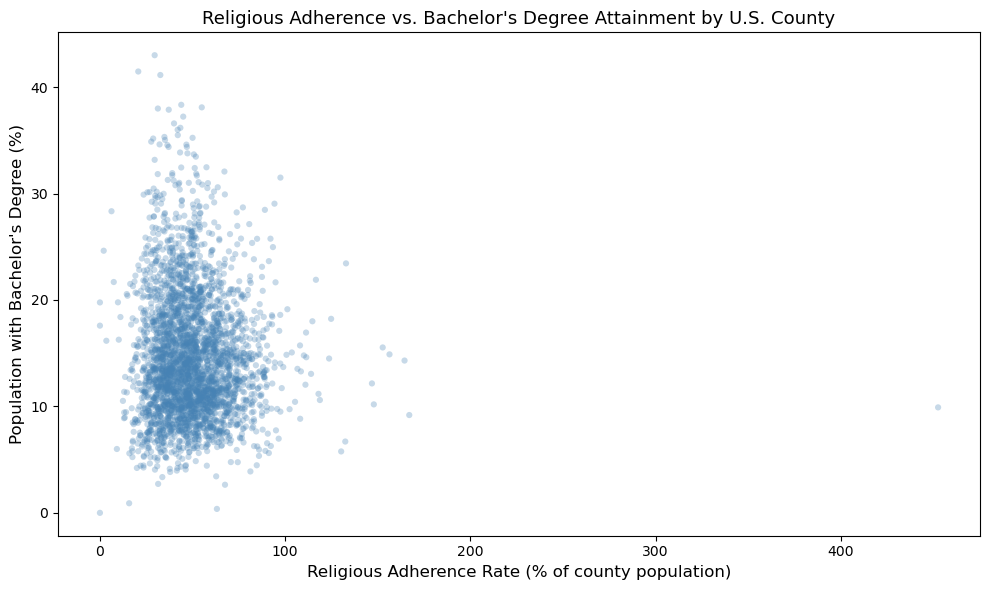

In [23]:
import matplotlib.pyplot as plt

# Scatter plot showing the relationship between religious adherence and bachelor's degree rates
# Each point represents one U.S. County
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_combined['TOTRATE_2020'], df_combined['pct_bachelors'], alpha=0.3, color='steelblue', edgecolors='none', s=20)

ax.set_xlabel("Religious Adherence Rate (% of county population)", fontsize=12)
ax.set_ylabel("Population with Bachelor's Degree (%)", fontsize=12)
ax.set_title("Religious Adherence vs. Bachelor's Degree Attainment by U.S. County", fontsize=13)

plt.tight_layout()
plt.show()

*Answer to research question:* The scatter plot shows a general negative trend - counties with higher religious adherence rates tend to have lower percentages of bachelor's degree holders. There is considerable variation, but the overall pattern supports the hypothesis that higher religiosity is associated with lower college education rates at the county level.

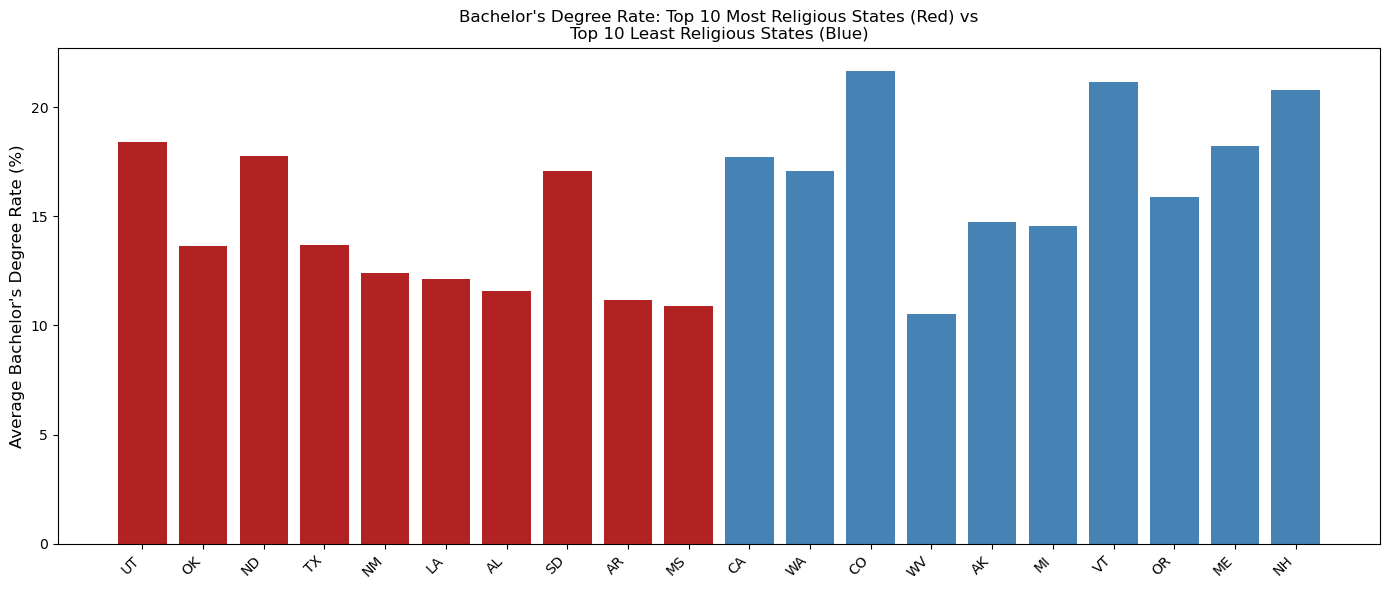

In [24]:
# Calculate average adherence and bachelor's rates by state
# then compare top 10 most vs least religious states 
state_avg = df_combined.groupby('STABBREV')[['TOTRATE_2020', 'pct_bachelors']].mean()
state_avg = state_avg.sort_values('TOTRATE_2020', ascending=False)

# Combine top 10 most religious (red) and bottom 10 least religious (blue) states
top_bottom = pd.concat([state_avg.head(10), state_avg.tail(10)])

fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(top_bottom))
bars = ax.bar(x, top_bottom['pct_bachelors'], color=['firebrick']*10 + ['steelblue']*10)

ax.set_xticks(x)
ax.set_xticklabels(top_bottom.index, rotation=45, ha='right')
ax.set_ylabel("Average Bachelor's Degree Rate (%)", fontsize=12)
ax.set_title("Bachelor's Degree Rate: Top 10 Most Religious States (Red) vs\nTop 10 Least Religious States (Blue)", fontsize=12)

plt.tight_layout()
plt.show()

*Answer to research question:* The bar chart reinforces the finding from the scatter plot. The 10 states with the highest average religious adherence rates (shown in red) generally have lower bachelor's degree attainment compared to the 10 least religious states (shown in blue). This supports the hypothesis that religiosity and college education are inversely related at the geographic level in the United States.

## Next Steps

I would investigate which specific religious traditions (e.g., Evangelical Protestant vs. Catholic vs. Mainline Protestant) drive the relationship most, as the dataset includes tradition-level adherence rates. I would also explore whether the relationship holds after controlling for confounding variables such as county income levels, rural vs. urban classification, and racial demographics. Additionally, I would examine how this relationship has changed over time by incorporating the religion census data from 2010 and earlier.